# Check uncertainty consistency between IFY's and CFY's using covariance data

In [1]:
import sandy

In [2]:
import numpy as np
import pandas as pd
import scipy
from scipy.stats import bootstrap

Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

## Get decay data from JEFF

In [4]:
tape_rdd = sandy.get_endf6_file("jeff_40", "decay", "all")

rdd = sandy.DecayData.from_endf6(tape_rdd)

In [5]:
tape_jeff40 = sandy.get_endf6_file("jeff_40", "nfpy", [922330, 922350, 942390, 942410])
fy_jeff40 = sandy.Fy.from_endf6(tape_jeff40)

In [6]:
tape_jeff33 = sandy.get_endf6_file("jeff_33", "nfpy", [922330, 922350, 942390, 942410])
fy_jeff33 = sandy.Fy.from_endf6(tape_jeff33)

In [7]:
file = "fy.jeff40"
text = tape_jeff40.write_string()
with open(file, mode="w") as f:
    f.write(text)

## Get fission yields from JEFF-4.0 and JEFF-3.3

In [8]:
fy_jeff40 = sandy.Fy.from_endf6(tape_jeff40)
fy_jeff33 = sandy.Fy.from_endf6(tape_jeff33)

## Get samples

This tests the entire sampling process.

In [9]:
nsmp = 50
sandy.sampling.run(f"{file} --samples {nsmp} --fycov".split())


========= SAMPLING CONFIGURATION =========
{ 'acer': False,
  'cov_energy_grid': 'csewg239',
  'file': 'fy.jeff40',
  'from_perturbations': False,
  'fycov': True,
  'loglevel': 'info',
  'mf': [31, 33, 35],
  'mt33': 'all',
  'njoy': None,
  'no_verbose': False,
  'only_perturbations': False,
  'processes': 1,
  'samples': 50,
  'seed31': None,
  'seed33': None,
  'seed34': None,
  'seed35': None,
  'show_njoy': False,
  'temperatures': None,
  'tqdm': False}

sampling | processing file: 'fy.jeff40'
sampling | ENDF-6 content: 4 MAT, 2 MF, 3 MT
sampling | detected MF=8/MT=454 (decay): using fission-yield path
########################################################
                GET PERTURBATIONS                       
########################################################
get_perturbations_fy | MULTI-ZAM | Fy=extracted with Fy.from_endf6
Fy.from_endf6 | reading ZAM=922330 kind=IFY
Fy.from_endf6 | reading ZAM=922330 kind=CFY
Fy.from_endf6 | reading ZAM=922350 kind=IFY
Fy.from_endf

In [10]:
outs = {k: sandy.Fy.from_endf6(sandy.Endf6.from_file(f"fy_{k}")) for k in range(nsmp)}

## Test 1: covariance for U-235 thermal

In [12]:
ZAM = 922350

In [11]:
cfys = pd.concat([v.apply_qmatrix(ZAM, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [13]:
jeff40_cfys = {
    "Nd148": fy_jeff40.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff40.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff40.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff40.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff40.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff40.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff40.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [14]:
jeff33_cfys = {
    "Nd148": fy_jeff33.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff33.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff33.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff33.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff33.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff33.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff33.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [15]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

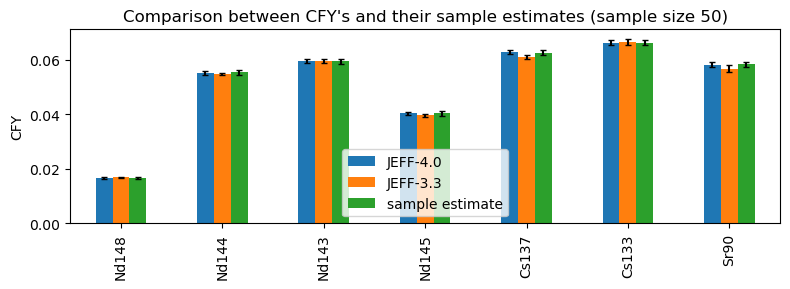

In [16]:
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.FY for k, v in jeff40_cfys.items()},
    "JEFF-4.0-STD": {k: v.DFY for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff33_cfys.items()},
    "JEFF-3.3-STD": {k: v.DFY for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(j4, left_index=True, right_index=True).merge(s, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={
        "JEFF-3.3": d["JEFF-3.3-STD"],
        "JEFF-4.0": d["JEFF-4.0-STD"],
        "sample estimate": d["SMP_STD"],
    },
    capsize=2,
    ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY",
    xlabel=None,
    title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})"
)

fig.tight_layout()

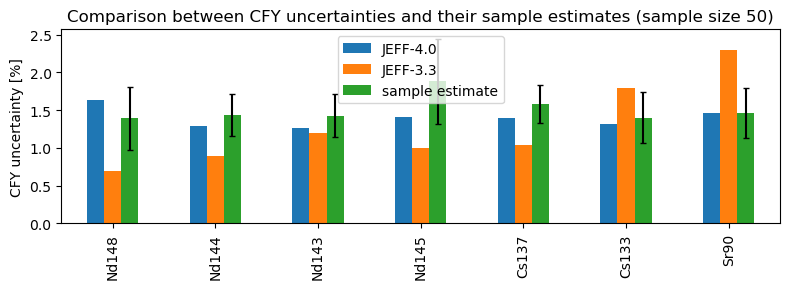

In [17]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.DFY / v.FY * 100 for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(s, left_index=True, right_index=True).merge(j4, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={"sample estimate": d["STD"] * 2},
    capsize=2, ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY uncertainty [%]",
    xlabel=None,
    title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})",
)

fig.tight_layout()

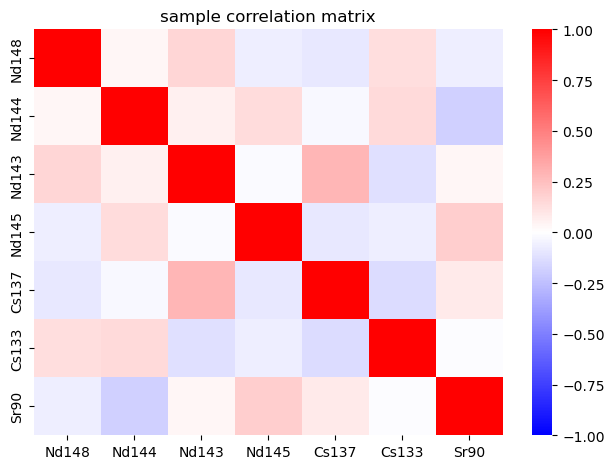

In [18]:
corr = pd.DataFrame(smp_cfys).corr()
fig, ax = plt.subplots()
sns.heatmap(corr, vmin=-1, vmax=1, cmap="bwr",ax=ax)
ax.set(title="sample correlation matrix")
fig.tight_layout()

## Test 2: covariance for Pu-239 thermal

In [37]:
ZAM = 942390

In [38]:
cfys = pd.concat([v.apply_qmatrix(ZAM, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [39]:
jeff40_cfys = {
    "Nd148": fy_jeff40.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff40.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff40.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff40.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff40.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff40.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff40.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [40]:
jeff33_cfys = {
    "Nd148": fy_jeff33.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff33.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff33.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff33.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff33.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff33.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff33.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [41]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

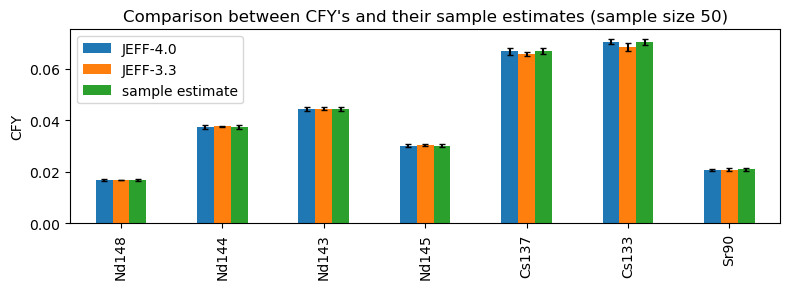

In [42]:
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.FY for k, v in jeff40_cfys.items()},
    "JEFF-4.0-STD": {k: v.DFY for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff33_cfys.items()},
    "JEFF-3.3-STD": {k: v.DFY for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(j4, left_index=True, right_index=True).merge(s, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={
        "JEFF-3.3": d["JEFF-3.3-STD"],
        "JEFF-4.0": d["JEFF-4.0-STD"],
        "sample estimate": d["SMP_STD"],
    },
    capsize=2,
    ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY",
    xlabel=None,
    title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})"
)

fig.tight_layout()

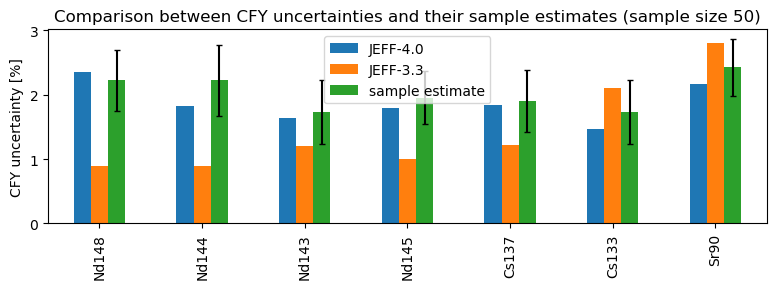

In [43]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.DFY / v.FY * 100 for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(s, left_index=True, right_index=True).merge(j4, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={"sample estimate": d["STD"] * 2},
    capsize=2, ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY uncertainty [%]",
    xlabel=None,
    title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})",
)

fig.tight_layout()

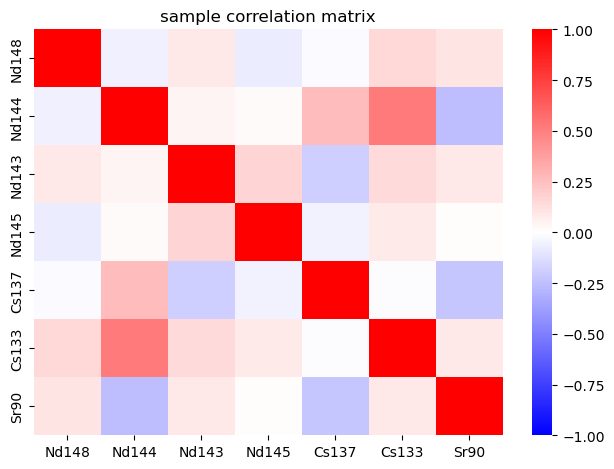

In [44]:
corr = pd.DataFrame(smp_cfys).corr()
fig, ax = plt.subplots()
sns.heatmap(corr, vmin=-1, vmax=1, cmap="bwr",ax=ax)
ax.set(title="sample correlation matrix")
fig.tight_layout()

## Test 3: covariance for U-233 thermal

In [45]:
ZAM = 922330

In [46]:
cfys = pd.concat([v.apply_qmatrix(ZAM, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [47]:
jeff40_cfys = {
    "Nd148": fy_jeff40.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff40.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff40.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff40.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff40.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff40.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff40.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [48]:
jeff33_cfys = {
    "Nd148": fy_jeff33.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff33.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff33.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff33.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff33.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff33.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff33.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [49]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

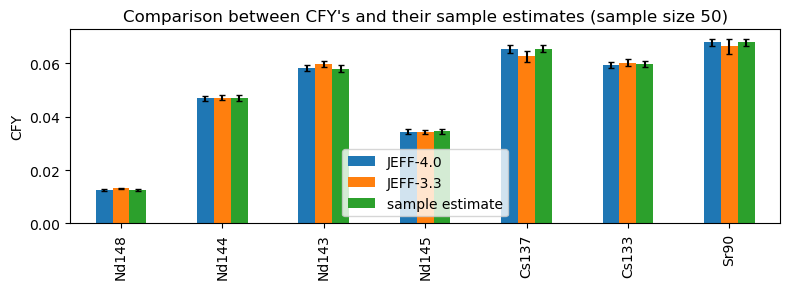

In [50]:
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.FY for k, v in jeff40_cfys.items()},
    "JEFF-4.0-STD": {k: v.DFY for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff33_cfys.items()},
    "JEFF-3.3-STD": {k: v.DFY for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(j4, left_index=True, right_index=True).merge(s, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={
        "JEFF-3.3": d["JEFF-3.3-STD"],
        "JEFF-4.0": d["JEFF-4.0-STD"],
        "sample estimate": d["SMP_STD"],
    },
    capsize=2,
    ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY",
    xlabel=None,
    title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})"
)

fig.tight_layout()

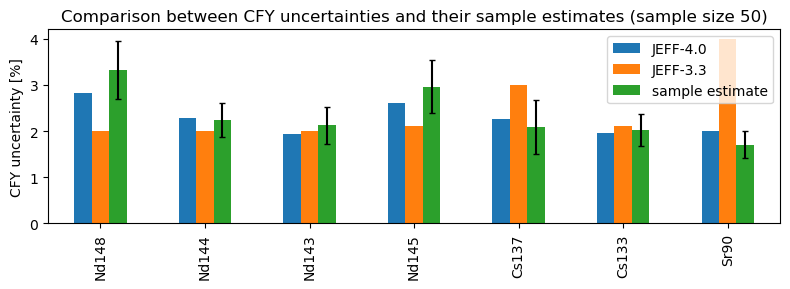

In [52]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.DFY / v.FY * 100 for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(s, left_index=True, right_index=True).merge(j4, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={"sample estimate": d["STD"] * 2},
    capsize=2, ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY uncertainty [%]",
    xlabel=None,
    title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})",
)

fig.tight_layout()

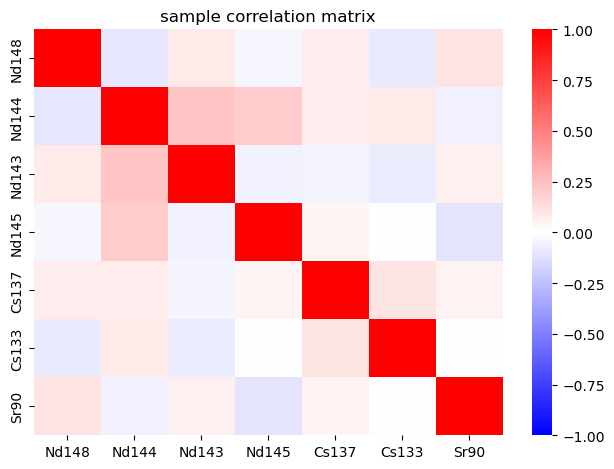

In [53]:
corr = pd.DataFrame(smp_cfys).corr()
fig, ax = plt.subplots()
sns.heatmap(corr, vmin=-1, vmax=1, cmap="bwr",ax=ax)
ax.set(title="sample correlation matrix")
fig.tight_layout()

## Test 4: covariance for Pu-241 thermal

In [54]:
ZAM = 942410

In [55]:
cfys = pd.concat([v.apply_qmatrix(ZAM, 0.0253, rdd)._expand_zap().assign(SMP=k) for k, v in outs.items()], ignore_index=True)

In [56]:
jeff40_cfys = {
    "Nd148": fy_jeff40.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff40.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff40.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff40.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff40.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff40.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff40.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [57]:
jeff33_cfys = {
    "Nd148": fy_jeff33.data.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd144": fy_jeff33.data.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd143": fy_jeff33.data.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Nd145": fy_jeff33.data.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs137": fy_jeff33.data.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Cs133": fy_jeff33.data.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
    "Sr90": fy_jeff33.data.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").squeeze(),
}

In [58]:
smp_cfys = {
    "Nd148": pd.Series({k: v.query("ZAP==601480 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd144": pd.Series({k: v.query("ZAP==601440 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd143": pd.Series({k: v.query("ZAP==601430 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Nd145": pd.Series({k: v.query("ZAP==601450 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs137": pd.Series({k: v.query("ZAP==551370 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Cs133": pd.Series({k: v.query("ZAP==551330 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
    "Sr90": pd.Series({k: v.query("ZAP==380900 and ZAM==@ZAM and E==0.0253 and MT==459").FY.squeeze() for k, v in cfys.groupby("SMP")}),
}

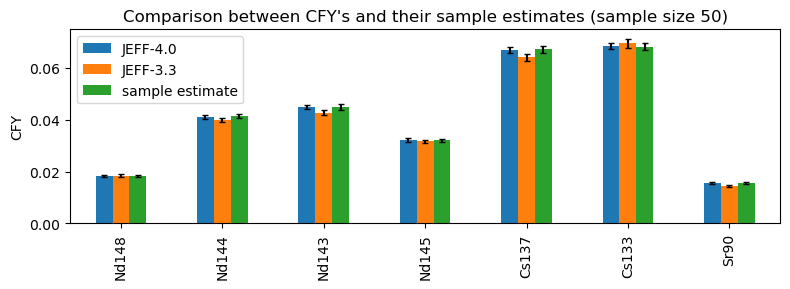

In [59]:
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.mean() for k, v in smp_cfys.items()},
    "SMP_STD": {k: v.std() for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.FY for k, v in jeff40_cfys.items()},
    "JEFF-4.0-STD": {k: v.DFY for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.FY for k, v in jeff33_cfys.items()},
    "JEFF-3.3-STD": {k: v.DFY for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(j4, left_index=True, right_index=True).merge(s, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={
        "JEFF-3.3": d["JEFF-3.3-STD"],
        "JEFF-4.0": d["JEFF-4.0-STD"],
        "sample estimate": d["SMP_STD"],
    },
    capsize=2,
    ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY",
    xlabel=None,
    title=f"Comparison between CFY's and their sample estimates (sample size {len(outs)})"
)

fig.tight_layout()

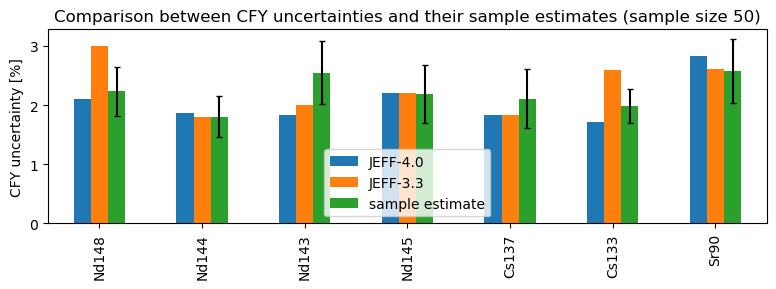

In [60]:
def foo(inp): return bootstrap((inp, ), lambda x: x.std()/x.mean()*100, confidence_level=0.95, n_resamples=100)
    
fig, ax = plt.subplots(figsize=(8, 3))

s = pd.DataFrame({
    "sample estimate": {k: v.std() / v.mean() * 100 for k, v in smp_cfys.items()},
    "STD": {k: foo(v).standard_error for k, v in smp_cfys.items()},
}).rename_axis("NUCL")

j3 = pd.DataFrame({
    "JEFF-3.3": {k: v.DFY / v.FY * 100 for k, v in jeff33_cfys.items()},
}).rename_axis("NUCL")

j4 = pd.DataFrame({
    "JEFF-4.0": {k: v.DFY / v.FY * 100 for k, v in jeff40_cfys.items()},
}).rename_axis("NUCL")

d = j3.merge(s, left_index=True, right_index=True).merge(j4, left_index=True, right_index=True).reset_index()

d.plot(
    kind='bar',
    x="NUCL",
    y=["JEFF-4.0", "JEFF-3.3", "sample estimate"],
    yerr={"sample estimate": d["STD"] * 2},
    capsize=2, ax=ax,
)
ax.legend()
ax.set(
    ylabel="CFY uncertainty [%]",
    xlabel=None,
    title=f"Comparison between CFY uncertainties and their sample estimates (sample size {len(outs)})",
)

fig.tight_layout()

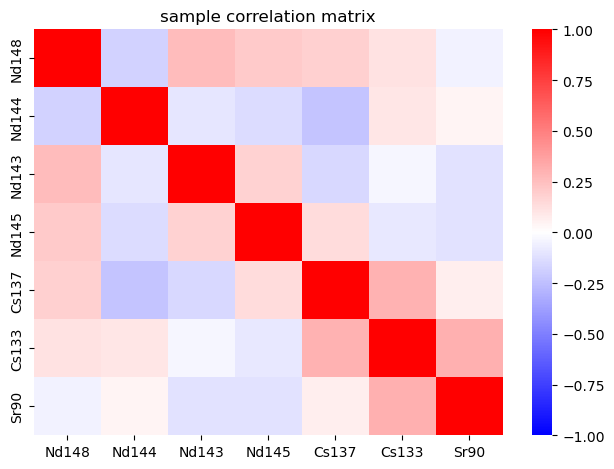

In [61]:
corr = pd.DataFrame(smp_cfys).corr()
fig, ax = plt.subplots()
sns.heatmap(corr, vmin=-1, vmax=1, cmap="bwr",ax=ax)
ax.set(title="sample correlation matrix")
fig.tight_layout()